# Multi-Robot Tutorial

This notebook shows how to work with multiple robots at the same time in RBS.
It covers three common cases:

- controlling robot instances independently
- combining robots into one synchronized `multi_robot` system
- defining coordinated bimanual tasks with absolute and relative motion

The examples use two Panda robots in MuJoCo, but the same ideas apply to larger multi-robot setups where the robots share a scene and have to be coordinated explicitly.


# Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from time import sleep, time
from copy import copy
import mediapy as media

from robotblockset.tools import get_rbs_path, print_xml
from robotblockset.transformations import map_pose, rot_x, rot_y, rot_z, rp2t, x2t, q2rpy, uniqueQuaternionPath
from robotblockset.trajectories import cline
from robotblockset.mujoco.tools_mjcf import print_body_tree
from robotblockset.mujoco.robots_pymujoco import mujoco_scene, panda

np.set_printoptions(precision=3, suppress=True, linewidth=100)

## Helper function for capturing robot states

The following function stores robot time, joint states, task-space states, and commanded references during motion. These recorded arrays are later used for plotting.


Capture measured and commanded robot states into global arrays for later plotting.


In [2]:
def CaptureMultiRobot(r):
    global it, trun, tt, qt, rqt, qdt, rqdt, xt, vt, rxt, rvt, mt
    q = np.asarray(r._actual.q)
    qd = np.asarray(r._actual.qdot)
    rq = np.asarray(r._command.q)
    rqd = np.asarray(r._command.qdot)
    x = np.asarray(r._actual.x)
    v = np.asarray(r._actual.v)
    rx = np.asarray(r._command.x)
    rv = np.asarray(r._command.v)
    mode = r._command.mode
    if it == 0:
        trun = np.asarray([r.Time], dtype=float)
        tt = np.asarray([r.t], dtype=float)
        qt = q.reshape(1, -1)
        qdt = qd.reshape(1, -1)
        rqt = rq.reshape(1, -1)
        rqdt = rqd.reshape(1, -1)
        xt = x.reshape((1,) + x.shape)
        vt = v.reshape((1,) + v.shape)
        rxt = rx.reshape((1,) + rx.shape)
        rvt = rv.reshape((1,) + rv.shape)
        mt = np.asarray([mode], dtype=float)
    else:
        trun = np.concatenate([trun, [r.Time]])
        tt = np.concatenate([tt, [r.t]])
        qt = np.vstack([qt, q.reshape(1, -1)])
        qdt = np.vstack([qdt, qd.reshape(1, -1)])
        rqt = np.vstack([rqt, rq.reshape(1, -1)])
        rqdt = np.vstack([rqdt, rqd.reshape(1, -1)])
        xt = np.concatenate([xt, x.reshape((1,) + x.shape)], axis=0)
        vt = np.concatenate([vt, v.reshape((1,) + v.shape)], axis=0)
        rxt = np.concatenate([rxt, rx.reshape((1,) + rx.shape)], axis=0)
        rvt = np.concatenate([rvt, rv.reshape((1,) + rv.shape)], axis=0)
        mt = np.concatenate([mt, [mode]])
    it += 1


# Initialization


## Prepare Scene

Load a MuJoCo scene that contains two Panda robots and inspect the generated body tree. This is useful when checking body names, mocap targets, and robot base frames used later in the notebook.


In [3]:
MODEL_PATH = get_rbs_path() + "/mujoco/mjcf_models/panda_2x_scene.xml"
scene = mujoco_scene(MODEL_PATH, show_camera=None, verbose=1)

In [4]:
print_body_tree(scene.spec.worldbody, scene.spec)

Body Tree for "world"
-Target
-Target1
-panda
--panda_link0
---panda_link1 (Joints: panda_joint1-HINGE[Actuator: panda_pos_joint1])
----panda_link2 (Joints: panda_joint2-HINGE[Actuator: panda_pos_joint2])
-----panda_link3 (Joints: panda_joint3-HINGE[Actuator: panda_pos_joint3])
------panda_link4 (Joints: panda_joint4-HINGE[Actuator: panda_pos_joint4])
-------panda_link5 (Joints: panda_joint5-HINGE[Actuator: panda_pos_joint5])
--------panda_link6 (Joints: panda_joint6-HINGE[Actuator: panda_pos_joint6])
---------panda_link7 (Joints: panda_joint7-HINGE[Actuator: panda_pos_joint7])
----------panda_flange
-----------panda_hand
------------panda_left_finger (Joints: panda_finger_joint1-SLIDE)
------------panda_right_finger (Joints: panda_finger_joint2-SLIDE)
-panda1
--panda1_link0
---panda1_link1 (Joints: panda1_joint1-HINGE[Actuator: panda1_pos_joint1])
----panda1_link2 (Joints: panda1_joint2-HINGE[Actuator: panda1_pos_joint2])
-----panda1_link3 (Joints: panda1_joint3-HINGE[Actuator: panda1

## Define Robots

Create two robot interfaces that point to the two Panda manipulators already present in the scene. Each interface can be used on its own, or both can later be wrapped into a combined multi-robot system.


In [5]:
r1 = panda(scene=scene)
r2 = panda(robot_name="panda1", scene=scene)

[RBS_INFO] [06:47:41] [panda_PyMuJoCo]: Robot connected to MuJoCo
[RBS_INFO] [06:47:42] [panda1_PyMuJoCo]: Robot connected to MuJoCo


Robots can be placed at different base poses before running coordinated examples. Here we move the MuJoCo mocap bodies that define the robot bases so the robots face each other with enough workspace overlap.


In [6]:
r1.SetMocapPose('panda',rp2t(rot_z(0*np.pi/2), [0, -0.4, 0]))
r2.SetMocapPose('panda1',rp2t(rot_z(0 *np.pi/2), [0, 0.4, 0]))
r1.Wait(0.1)

After the robot base frames are changed in the simulator, the robot interfaces must refresh their internal base poses. In MuJoCo this is done by reading the current pose of the corresponding base body from the model.


In [7]:
print("Robot 1 base:\n", r1.UpdateRobotBaseFromModel())
print("Robot 2 base:\n", r2.UpdateRobotBaseFromModel())

Robot 1 base:
 [[ 1.   0.   0.   0. ]
 [ 0.   1.   0.  -0.4]
 [ 0.   0.   1.   0. ]
 [ 0.   0.   0.   1. ]]
Robot 2 base:
 [[1.  0.  0.  0. ]
 [0.  1.  0.  0.4]
 [0.  0.  1.  0. ]
 [0.  0.  0.  1. ]]


For convenience we first move both robots to their home configurations.


# Independent Robots

The first option is to control both robots independently. In that case each robot keeps its own controller, state, and task definition, while the user is responsible for issuing commands in the desired temporal order.


In [8]:
r1.JMove(r1.q_home)
r2.JMove(r1.q_home)

0

Because commands are normally executed sequentially, RBS allows a robot motion to run in a separate thread. This makes it possible to start a motion on one robot and immediately continue by commanding the other robot.


In [9]:
th1 = r1.CMoveFor([0.1, -0.1, 0], 2, asynchronous=True)
while th1.is_alive():
    print("Robot is moving...")
    sleep(0.5)
print("Motion finished")

Robot is moving...
Robot is moving...
Robot is moving...
Robot is moving...
Robot is moving...
Robot is moving...
Robot is moving...
Motion finished


After a motion command with `asynchronous=True`, Python continues to execute the next instructions immediately. If the rest of the program depends on both robots having finished, the worker thread must be synchronized explicitly, for example with `join()`.


In [10]:
th1 = r1.JMove(r1.q_home, 3, asynchronous=True)
r2.CMoveFor([0.1, -0.1, 0], 2)
print("Robot 2 motion finished")
if th1.is_alive():
    print("Robot is moving...")
th1.join()
print("Both robots finished motion")

Robot 2 motion finished
Robot is moving...
Both robots finished motion


> ⚠️ **Warning:** Only one movement command can be executed at any given time. 


In [11]:
th1 = r1.CMoveFor([0, 0.4, -0.1], 2, asynchronous=True)
r1.JMove(r1.q_home)

[RBS_WARN] [1774932502.948323488] [panda_PyMuJoCo]: JMove not executed due to active threads!


5

To reset threads use `Stop` command.

In [12]:
r1.Stop()
r2.Stop()

# Multi-Robot Systems

RBS also supports **multi-robot** systems. The API wraps several single-robot instances into one combined object.

A multi-robot exposes a concatenated joint vector and per-robot task-space state, while each robot still keeps its own base, TCP, gripper, and sensors. This makes it possible to plan and execute synchronized motion with one high-level command and forms the basis for specialized dual-arm and bimanual systems.

The multi-robot system can be created using one of the following classes:

| Class | Description |
| --- | --- |
| `multi_robot` | Combined dual-robot system with two task spaces: robot 1 and robot 2. |
| `bimanual_robot` | Bimanual system: relative task from EE1 to EE2; absolute task from base1 to EE1 (robot 1). |
| `bimanual_robot_mean` | Bimanual system: relative task from EE1 to EE2; absolute task uses the mean pose of both robots (per class implementation). |

Arguments for `multi_robots` classes:

| Argument | Default | Description |
| --- | --- | --- |
| `robots` | required | Tuple of robot instances in the combined system. For bimanual classes, exactly two robots are required; the end-effector of the first robot is the base for the relative task. |
| `robot_name` | `multirobot` | Display name of the combined system. |
| `tool_name` | `Tool` | Tool-center-point name used by the combined system. |
| `newtask` | `False` | If `True`, a fresh task-space controller is created for the combined system. |
| `simtime` | `None` | Simulation-time callback inherited from the first robot when not provided explicitly. |
| `robot_distance` | `0.8` | Nominal separation used by some visualization and setup utilities. |


## Synchronous Motion of Multiple Robots (`multi_robot`)

A `multi_robot` combines several robots into one coordinated system. Each robot still has its own task space, but the command execution is synchronized so all robots move as part of one trajectory.


In [13]:
from robotblockset.multi_robots import multi_robot
r = multi_robot((r1, r2), robot_name="DualRobot")

> ?? **Note:** Class `multi_robot` is the only one that supports combining more than two robots into one wrapper.


The TCP of a `multi_robot` is stored per robot, so the combined system keeps one TCP definition for each manipulator.


In [14]:
for rob in r.robots:
    print(rob.TCP)

[[ 0.7071  0.7071  0.0000  0.0000]
 [-0.7071  0.7071  0.0000  0.0000]
 [ 0.0000  0.0000  1.0000  0.1034]
 [ 0.0000  0.0000  0.0000  1.0000]]
[[ 0.7071  0.7071 -0.0000 -0.0000]
 [-0.7071  0.7071  0.0000 -0.0000]
 [ 0.0000  0.0000  1.0000  0.1034]
 [ 0.0000  0.0000  0.0000  1.0000]]


In [15]:
r.TCP

array([[[ 0.7071,  0.7071,  0.0000,  0.0000],
        [-0.7071,  0.7071,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  1.0000,  0.1034],
        [ 0.0000,  0.0000,  0.0000,  1.0000]],

       [[ 0.7071,  0.7071, -0.0000, -0.0000],
        [-0.7071,  0.7071,  0.0000, -0.0000],
        [ 0.0000,  0.0000,  1.0000,  0.1034],
        [ 0.0000,  0.0000,  0.0000,  1.0000]]])

Now we can move all robots simultaneously with one command.


In [16]:
r.JMove(r.q_home,2)


0

We can inspect the states of each robot separately and compare them with the concatenated state stored in the combined system.


In [17]:
for rob in r.robots:
    print(f"Joint states of robot {rob.Name}:\n {rob.q}")


Joint states of robot panda_PyMuJoCo:
 [ 0.0064 -0.7734  0.0109 -2.3587  0.0036  1.5731  0.7967]
Joint states of robot panda1_PyMuJoCo:
 [-0.0037 -0.7780 -0.0003 -2.3580 -0.0005  1.5715  0.7811]


In [18]:
print(f"Joint states of multi-robot {r.Name}:\n {r.q}")

Joint states of multi-robot DualRobot:
 [ 0.0064 -0.7734  0.0109 -2.3587  0.0036  1.5731  0.7967 -0.0037 -0.7780 -0.0003 -2.3580 -0.0005
  1.5715  0.7811]


In [19]:
for rob in r.robots:
    print(f"Task poses of robot {rob.Name}:\n {rob.x}")


Task poses of robot panda_PyMuJoCo:
 [ 0.3089 -0.3937  0.4827 -0.0021 -1.0000 -0.0015  0.0058]
Task poses of robot panda1_PyMuJoCo:
 [ 0.3077  0.3988  0.4838 -0.0002 -1.0000 -0.0002  0.0042]


In [20]:
print(f"Task poses of multi-robot {r.Name}:\n {r.x}")

Task poses of multi-robot DualRobot:
 [[ 0.3094 -0.3931  0.4829 -0.0021 -1.0000 -0.0012  0.0056]
 [ 0.3076  0.3989  0.4838 -0.0002 -1.0000 -0.0002  0.0042]]


Define new task-space targets and visualize them in the simulator using MuJoCo `Target` objects.

For moving markers we use one of the robot interfaces because `multi_robot` itself is not attached directly to the simulator scene.

> To see the orientations of the target frames, enable Site group 4 in the simulator window.


In [21]:
x0 = r.x
x0[0] = map_pose(p=[0.3, -0.2, 0.5], R=rot_z(np.pi/2, out="R") @ rot_x(np.pi, out="R"))
x0[1] = map_pose(p=[0.3, 0.2, 0.5], R=rot_z(-np.pi/2, out="R") @ rot_x(np.pi, out="R"))
r1.SetMocapPose("Target", x0[0])
r1.SetMocapPose("Target1", x0[1])

Move both robots simultaneously and record the trajectory for later plots.


In [22]:
r.JMove(r.q_home)
r.Wait(1)
r.SetCaptureCallback(CaptureMultiRobot)
r.ResetTime()
it = 0
r.StartCapture()
r.CMove(x0, t=2)
r.Wait(1)
r.StopCapture()

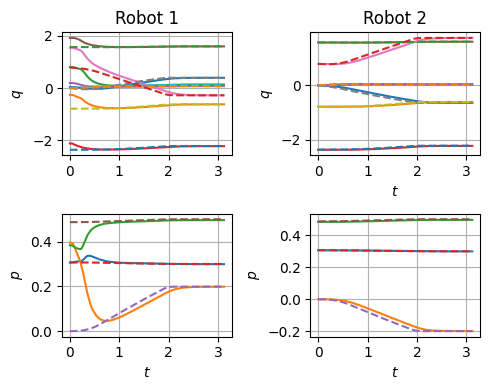

In [23]:
fig, ax = plt.subplots(2, 2, num=1, figsize=(5, 4))
ax[0, 0].plot(tt, qt[:, :r1.nj], "-")
ax[0, 0].plot(tt, rqt[:, :r1.nj], "--")
ax[0, 0].grid()
ax[0, 0].set_ylabel("$q$")
ax[0, 0].set_title("Robot 1")

ax[0, 1].plot(tt, qt[:, r1.nj:], "-")
ax[0, 1].plot(tt, rqt[:, r1.nj:], "--")
ax[0, 1].grid()
ax[0, 1].set_ylabel("$q$")
ax[0, 1].set_xlabel("$t$")
ax[0, 1].set_title("Robot 2")

ax[1, 0].plot(tt, xt[:, 0, :3], "-")
ax[1, 0].plot(tt, rxt[:, 0, :3], "--")
ax[1, 0].grid()
ax[1, 0].set_ylabel("$p$")
ax[1, 0].set_xlabel("$t$")

ax[1, 1].plot(tt, xt[:, 1, :3], "-")
ax[1, 1].plot(tt, rxt[:, 1, :3], "--")
ax[1, 1].grid()
ax[1, 1].set_ylabel("$p$")
ax[1, 1].set_xlabel("$t$")

plt.tight_layout()

In [24]:
r.JMove(r.q_home)

0

The original robot objects can still be moved independently.


In [25]:
r1.JMove(r1.q_home)

0

> ?? **Warning:** If one or more robots are moved independently, the cached state of the `multi_robot` wrapper is not updated automatically. Before issuing the next combined command, refresh the wrapper state explicitly.


Compare the state of each robot with the combined state stored in the wrapper.


In [26]:
for rob in r.robots:
    print(f"Joint states of robot {rob.Name}:\n {rob.q}")

print(f"Joint states of multi-robot {r.Name}:\n {r.q}")

Joint states of robot panda_PyMuJoCo:
 [ 0.0000 -0.7845  0.0002 -2.3625 -0.0003  1.5697  0.7854]
Joint states of robot panda1_PyMuJoCo:
 [-0.0038 -0.7835  0.0005 -2.3616 -0.0002  1.5698  0.7912]
Joint states of multi-robot DualRobot:
 [ 0.0023 -0.7835  0.0009 -2.3616  0.0001  1.5698  0.7789 -0.0038 -0.7835  0.0005 -2.3616 -0.0002
  1.5698  0.7912]


Here we update the combined state explicitly.


In [27]:
r.GetState()
for rob in r.robots:
    print(f"Joint states of robot {rob.Name}:\n {rob.q}")

print(f"Joint states of multi-robot {r.Name}:\n {r.q}")

Joint states of robot panda_PyMuJoCo:
 [ 0.0000 -0.7845  0.0002 -2.3625 -0.0003  1.5697  0.7854]
Joint states of robot panda1_PyMuJoCo:
 [-0.0000 -0.7845  0.0002 -2.3625 -0.0003  1.5697  0.7854]
Joint states of multi-robot DualRobot:
 [ 0.0000 -0.7845  0.0002 -2.3625 -0.0003  1.5697  0.7854 -0.0000 -0.7845  0.0002 -2.3625 -0.0003
  1.5697  0.7854]


> ?? **Note:** The commanded states of the `multi_robot` wrapper and the commanded states of the underlying robot instances are independent.


So the commanded targets used for trajectory generation can still differ even after the measured state has been refreshed.


In [28]:
for rob in r.robots:
    print(f"Joint states of robot {rob.Name}:\n {rob.q_ref}")

print(f"Joint states of multi-robot {r.Name}:\n {r.q_ref}")

Joint states of robot panda_PyMuJoCo:
 [ 0.0000 -0.7854  0.0000 -2.3562  0.0000  1.5708  0.7854]
Joint states of robot panda1_PyMuJoCo:
 [ 0.0000 -0.7854  0.0000 -2.3562 -0.0000  1.5708  0.7854]
Joint states of multi-robot DualRobot:
 [ 0.0000 -0.7854  0.0000 -2.3562  0.0000  1.5708  0.7854  0.0000 -0.7854  0.0000 -2.3562 -0.0000
  1.5708  0.7854]


They must be synchronized manually. In many practical cases, when the robots are not compliant, `ResetCurrentTarget()` is the simplest way to align the commanded target with the current measured state.


In [29]:
r.ResetCurrentTarget()
for rob in r.robots:
    print(f"Joint states of robot {rob.Name}:\n {rob.q_ref}")

print(f"Joint states of multi-robot {r.Name}:\n {r.q_ref}")

Joint states of robot panda_PyMuJoCo:
 [ 0.0000 -0.7854  0.0000 -2.3562  0.0000  1.5708  0.7854]
Joint states of robot panda1_PyMuJoCo:
 [ 0.0000 -0.7854  0.0000 -2.3562 -0.0000  1.5708  0.7854]
Joint states of multi-robot DualRobot:
 [ 0.0000 -0.7845  0.0002 -2.3625 -0.0003  1.5697  0.7854 -0.0000 -0.7845  0.0002 -2.3625 -0.0003
  1.5697  0.7854]


## Bimanual Robots

Bimanual robots use two coordinated manipulators to grasp, move, and manipulate objects in ways that are difficult for a single arm. Compared to `multi_robot`, the key difference is that the task is expressed through coordinated variables instead of two completely independent end-effector targets.


**Task Definition**

In this library, bimanual coordination is expressed with two task definitions:

- an **absolute task**, which describes the global motion of the pair
- a **relative task**, which describes how the two end-effectors are positioned with respect to each other


In [30]:
from robotblockset.multi_robots import bimanual_robot
r = bimanual_robot((r1, r2))


Move the robots to the home configuration and store the initial task poses.


In [31]:
r.JMove(r.q_home)
x0 = r.x_ref

> ?? **Note:** Joint-space motion is the same for all multi-robot systems.


In operational space the system has two tasks: relative and absolute. The task-space poses are stored as a 2D array, where the first row corresponds to the relative task and the second row to the absolute task.


In [32]:
print(f"Relative task pose: {x0[0]}")
print(f"Absolute task pose: {x0[1]}")

Relative task pose: [-0.0000 -0.8000  0.0000 -1.0000 -0.0000  0.0000  0.0000]
Absolute task pose: [ 0.3069 -0.4000  0.4869  0.0000 -1.0000  0.0000 -0.0000]


Define new task-space targets and visualize the desired end-effector poses with MuJoCo markers.

In this `bimanual_robot` definition, the absolute task corresponds to the pose of the first robot.


In [33]:
x0[0] = map_pose(p=[0, -0.5, 0])
x0[1] = map_pose(p=[0.3, -0.2, 0.5], R=rot_z(0*np.pi/4, out="R") @ rot_x(np.pi, out="R"))
r1.SetMocapPose("Target", x0[1])
r1.SetMocapPose("Target1", x2t(x0[1]) @ x2t(x0[0]))
print(f"Target pose:\n {x0}")

Target pose:
 [[ 0.0000 -0.5000  0.0000  1.0000  0.0000  0.0000  0.0000]
 [ 0.3000 -0.2000  0.5000  0.0000 -1.0000 -0.0000 -0.0000]]


Move to the target and record the response.


In [34]:
r.JMove(r.q_home)
r.Wait(1)
r.SetCaptureCallback(CaptureMultiRobot)
r.ResetTime()
it = 0
r.StartCapture()
r.CMove(x0, t=2)
r.Wait(1)
r.StopCapture()

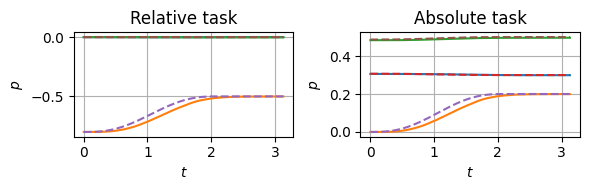

In [35]:
fig, ax = plt.subplots(1, 2, num=1, figsize=(6, 2))
ax = ax.flatten()
ax[0].plot(tt, xt[:, 0, :3], "-")
ax[0].plot(tt, rxt[:, 0, :3], "--")
ax[0].grid()
ax[0].set_ylabel("$p$")
ax[0].set_xlabel("$t$")
ax[0].set_title("Relative task")

ax[1].plot(tt, xt[:, 1, :3], "-")
ax[1].plot(tt, rxt[:, 1, :3], "--")
ax[1].grid()
ax[1].set_ylabel("$p$")
ax[1].set_xlabel("$t$")
ax[1].set_title("Absolute task")

plt.tight_layout()

Define another task-space target pose. Note that `r.nr` is the number of robots in the system, which here also matches the number of task entries to fill.


In [36]:
x1 = np.zeros((r.nr, 7))
x1[0] = map_pose(p=[0, -0.5, 0], R=rot_z(-np.pi/4, out="R"))
x1[1] = map_pose(p=[0.3, -0.2, 0.3], R=rot_z(0*np.pi/4, out="R") @ rot_x(np.pi, out="R"))
r1.SetMocapPose("Target", x1[1])
r1.SetMocapPose("Target1", x2t(x1[1]) @ x2t(x1[0]))

Then move to the new target.


In [37]:
r.SetCaptureCallback(CaptureMultiRobot)
r.ResetTime()
it = 0
r.StartCapture()
r.CMove(x1, t=2)
r.Wait(1)
r.StopCapture()

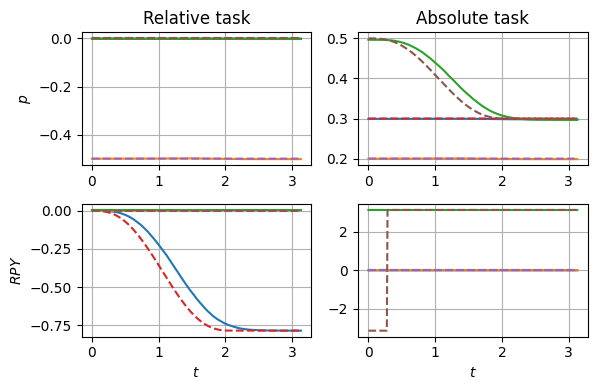

In [38]:
fig, ax = plt.subplots(2, 2, num=1, figsize=(6, 4))
ax = ax.flatten()
ax[0].plot(tt, xt[:, 0, :3], "-")
ax[0].plot(tt, rxt[:, 0, :3], "--")
ax[0].grid()
ax[0].set_ylabel("$p$")
ax[0].set_title("Relative task")

ax[1].plot(tt, xt[:, 1, :3], "-")
ax[1].plot(tt, rxt[:, 1, :3], "--")
ax[1].grid()
ax[1].set_title("Absolute task")

ax[2].plot(tt, q2rpy(uniqueQuaternionPath(xt[:, 0, 3:])), "-")
ax[2].plot(tt, q2rpy(uniqueQuaternionPath(rxt[:, 0, 3:])), "--")
ax[2].grid()
ax[2].set_ylabel("$RPY$")
ax[2].set_xlabel("$t$")

ax[3].plot(tt, q2rpy(uniqueQuaternionPath(xt[:, 1, 3:])), "-")
ax[3].plot(tt, q2rpy(uniqueQuaternionPath(rxt[:, 1, 3:])), "--")
ax[3].grid()
ax[3].set_xlabel("$t$")

plt.tight_layout()

## Functional Redundancy


Select the functional redundancy so that the task contains only the absolute pose, that is, the pose of the first robot.


In [39]:
r.CMove(x0)
r.Wait(1)
r.SetCaptureCallback(CaptureMultiRobot)
r.ResetTime()
it = 0
r.StartCapture()
r.CMove(x1, task_DOF=[0, 0, 0, 0, 0, 0,   1, 1, 1, 1, 1, 1], null_space_task="None")
r.Wait(1)
r.StopCapture()

Only the first robot moves in this case. As a result, the relative task pose changes during the motion because the second arm is not constrained.


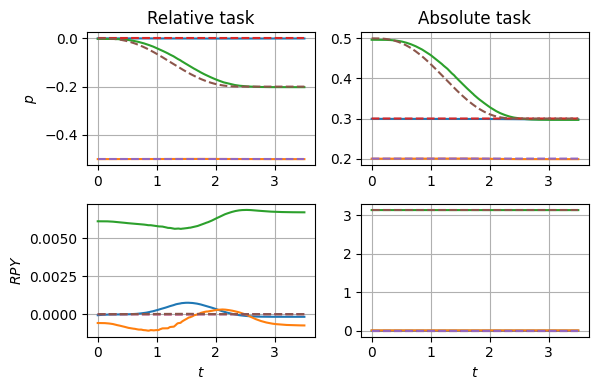

In [40]:
fig, ax = plt.subplots(2, 2, num=1, figsize=(6, 4))
ax = ax.flatten()
ax[0].plot(tt, xt[:, 0, :3], "-")
ax[0].plot(tt, rxt[:, 0, :3], "--")
ax[0].grid()
ax[0].set_ylabel("$p$")
ax[0].set_title("Relative task")

ax[1].plot(tt, xt[:, 1, :3], "-")
ax[1].plot(tt, rxt[:, 1, :3], "--")
ax[1].grid()
ax[1].set_title("Absolute task")

ax[2].plot(tt, q2rpy(uniqueQuaternionPath(xt[:, 0, 3:])), "-")
ax[2].plot(tt, q2rpy(uniqueQuaternionPath(rxt[:, 0, 3:])), "--")
ax[2].grid()
ax[2].set_ylabel("$RPY$")
ax[2].set_xlabel("$t$")

ax[3].plot(tt, q2rpy(uniqueQuaternionPath(xt[:, 1, 3:])), "-")
ax[3].plot(tt, q2rpy(uniqueQuaternionPath(rxt[:, 1, 3:])), "--")
ax[3].grid()
ax[3].set_xlabel("$t$")

plt.tight_layout()

Now repeat a similar experiment with the redundancy chosen so that the task contains only the relative pose between the two end-effectors.


In [41]:
r.CMove(x0)
r.Wait(1)
r.SetCaptureCallback(CaptureMultiRobot)
r.ResetTime()
it = 0
r.StartCapture()
r.CMove(x1, task_DOF=[1, 1, 1, 1, 1, 1,   0, 0, 0, 0, 0, 0], null_space_task="None")
r.Wait(1)
r.StopCapture()

In this case both robots move. The relative pose follows the command, while the absolute pose changes through null-space motion.


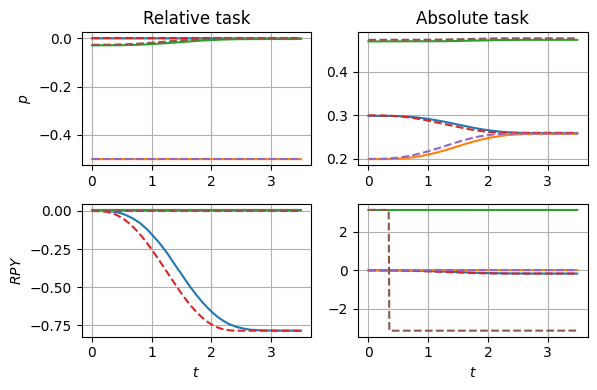

In [42]:
fig, ax = plt.subplots(2, 2, num=1, figsize=(6, 4))
ax = ax.flatten()
ax[0].plot(tt, xt[:, 0, :3], "-")
ax[0].plot(tt, rxt[:, 0, :3], "--")
ax[0].grid()
ax[0].set_ylabel("$p$")
ax[0].set_title("Relative task")

ax[1].plot(tt, xt[:, 1, :3], "-")
ax[1].plot(tt, rxt[:, 1, :3], "--")
ax[1].grid()
ax[1].set_title("Absolute task")

ax[2].plot(tt, q2rpy(uniqueQuaternionPath(xt[:, 0, 3:])), "-")
ax[2].plot(tt, q2rpy(uniqueQuaternionPath(rxt[:, 0, 3:])), "--")
ax[2].grid()
ax[2].set_ylabel("$RPY$")
ax[2].set_xlabel("$t$")

ax[3].plot(tt, q2rpy(uniqueQuaternionPath(xt[:, 1, 3:])), "-")
ax[3].plot(tt, q2rpy(uniqueQuaternionPath(rxt[:, 1, 3:])), "--")
ax[3].grid()
ax[3].set_xlabel("$t$")

plt.tight_layout()

## Path


Move to a new pose that will serve as the starting point for the path example.


In [43]:
x2 = x0.copy()
x2[1] = r.x_ref[1]
r1.SetMocapPose("Target",x2[1])
r1.SetMocapPose("Target1",x2t(x2[1]) @ x2t(x2[0]))
r.CMove(x2)


0

Generate several target poses and visualize them before executing the path motion.


In [44]:
x4 = x0.copy()
x4[0] = map_pose(p=[0, -0.3, 0], R=rot_z(-np.pi/4, out="R"))
x4[1] = map_pose(p=[0.2, -0.1, 0.4], R=rot_y(np.pi/6, out="R") @ rot_z(np.pi/4, out="R") @ rot_x(np.pi, out="R"))
tsamp=0.01
tt = np.arange(0, 1+tsamp, tsamp)
path_x = np.zeros((tt.size, 2, 7))
for i in range(r.nr):
    path_x[:, i, :] = cline(x0[i], x4[i],tt)[0]
r1.SetMocapPose("Target",x4[1])
r1.SetMocapPose("Target1",x2t(x4[1]) @ x2t(x4[0]))

Execute a path motion through the selected target poses and record the evolution of the relative and absolute tasks.


In [45]:
r.CMove(x0)
r.Wait(1)
r.SetCaptureCallback(CaptureMultiRobot)
r.ResetTime()
it = 0
r.StartCapture()
r.CPath(path_x, 4)
r.Wait(1)
r.StopCapture()

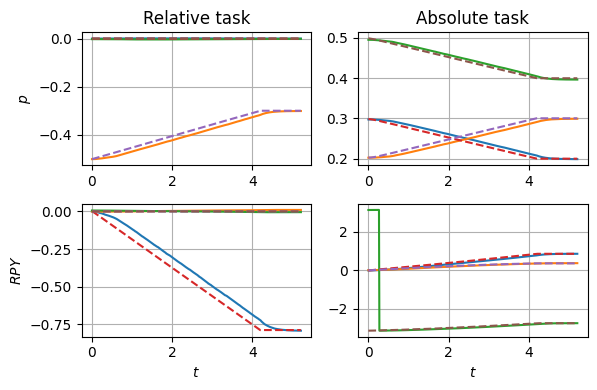

In [46]:
fig, ax = plt.subplots(2, 2, num=1, figsize=(6, 4))
ax = ax.flatten()
ax[0].plot(tt, xt[:, 0, :3], "-")
ax[0].plot(tt, rxt[:, 0, :3], "--")
ax[0].grid()
ax[0].set_ylabel("$p$")
ax[0].set_title("Relative task")

ax[1].plot(tt, xt[:, 1, :3], "-")
ax[1].plot(tt, rxt[:, 1, :3], "--")
ax[1].grid()
ax[1].set_title("Absolute task")

ax[2].plot(tt, q2rpy(uniqueQuaternionPath(xt[:, 0, 3:])), "-")
ax[2].plot(tt, q2rpy(uniqueQuaternionPath(rxt[:, 0, 3:])), "--")
ax[2].grid()
ax[2].set_ylabel("$RPY$")
ax[2].set_xlabel("$t$")

ax[3].plot(tt, q2rpy(uniqueQuaternionPath(xt[:, 1, 3:])), "-")
ax[3].plot(tt, q2rpy(uniqueQuaternionPath(rxt[:, 1, 3:])), "--")
ax[3].grid()
ax[3].set_xlabel("$t$")

plt.tight_layout()